<a href="https://colab.research.google.com/github/jamesharrison2005/IMDB-movie-feature-predictions/blob/main/IMDB_Feature_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Load and Identify key features

In [ ]:
dataset = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Data Science/Assignment2/imdb_kaggle.csv')
dataset.head()

,rank,year,duration,age_limit,rating,numberof_ratings,Metascore,description,name
0,1,1994,2h 22m,15,9.3,(2.9M),82.0,"Over the course of several years, two convicts...",The Shawshank Redemption
1,2,1972,2h 55m,15,9.2,(2M),100.0,The aging patriarch of an organized crime dyna...,The Godfather
2,3,2008,2h 32m,12A,9.0,(2.9M),84.0,When the menace known as the Joker wreaks havo...,The Dark Knight
3,4,2003,3h 21m,12A,9.0,(2M),94.0,Gandalf and Aragorn lead the World of Men agai...,The Lord of the Rings: The Return of the King
4,5,1993,3h 15m,15,9.0,(1.5M),95.0,"In German-occupied Poland during World War II,...",Schindler's List


In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   rank              1000 non-null   int64  
 1   year              1000 non-null   int64  
 2   duration          1000 non-null   object 
 3   age_limit         997 non-null    object 
 4   rating            1000 non-null   float64
 5   numberof_ratings  1000 non-null   object 
 6   Metascore         842 non-null    float64
 7   description       1000 non-null   object 
 8   name              1000 non-null   object 
dtypes: float64(2), int64(2), object(5)
memory usage: 70.4+ KB


In [ ]:
dataset.describe()

,rank,year,rating,Metascore
count,1000.000000,1000.000000,1000.000000,842.000000
mean,500.500000,1991.842000,7.972800,79.332542
std,288.819436,24.411861,0.273633,11.976835
min,1.000000,1920.000000,7.600000,28.000000
25%,250.750000,1975.000000,7.800000,72.000000
50%,500.500000,1999.000000,7.900000,81.000000
75%,750.250000,2012.000000,8.100000,88.000000
max,1000.000000,2024.000000,9.300000,100.000000


# Cleaning Dataset
To analyse the data effectively and predict outcomes, data cleaning and pre-processing must be performed to ensure the data is ready to be used

### Clean ratings feature
currently number of ratings is a string that is stored as (2M) This cannot be used for analysis. It must be each value must be converted to and integer e.g 2000000.

In [ ]:
def clean_ratings(val):
  cleaned_val = str(val).replace('(', '').replace(')', '').replace(',', '').strip()
  if 'M' in cleaned_val:
    num_str = cleaned_val.replace('M', '')
    return int(float(num_str) * 1_000_000)
  elif 'K' in cleaned_val:
    num_str = cleaned_val.replace('K', '')
    return int(float(num_str) * 1_000)
  else:
    return int(float(cleaned_val))

dataset['numberof_ratings_int'] = dataset['numberof_ratings'].apply(clean_ratings)
dataset[['name', 'numberof_ratings', 'numberof_ratings_int']].head()

,name,numberof_ratings,numberof_ratings_int
0,The Shawshank Redemption,(2.9M),2900000
1,The Godfather,(2M),2000000
2,The Dark Knight,(2.9M),2900000
3,The Lord of the Rings: The Return of the King,(2M),2000000
4,Schindler's List,(1.5M),1500000


### Change Duration to minutes

as it stands duration is currently stored as a string (e.g 2h 30m). This is an issue because a string can't be used for calculation. To fix this it should be converted to minutes only (2h 30m - > 150)

In [ ]:
def minute_conversion(duration):
  hours = 0
  mins = 0
  if 'h' in duration:
    hours = int(duration.split('h')[0])
    if 'm' in duration:
      mins = int(duration.split('h')[1].split('m')[0])
  elif 'm' in duration:
    mins = int(duration.split('m')[0])
  return (hours * 60) + mins

dataset['duration_mins'] = dataset['duration'].apply(minute_conversion)
dataset[['name', 'duration', 'duration_mins']].head()

,name,duration,duration_mins
0,The Shawshank Redemption,2h 22m,142
1,The Godfather,2h 55m,175
2,The Dark Knight,2h 32m,152
3,The Lord of the Rings: The Return of the King,3h 21m,201
4,Schindler's List,3h 15m,195


### Convert PG and other agelimits to numerical value using one-hot encoding
this turns categorical data into numerical data allowing me to manipulate and train algorithms on it for prediction

In [ ]:
most_common_rating = dataset['age_limit'].mode()[0]
dataset['age_limit'] = dataset['age_limit'].fillna(most_common_rating)
# one hot encode columns
dataset = pd.get_dummies(dataset, columns=['age_limit'], prefix='age') # uses get_dummies
# turns each unique value into seperate columns for analysis and prediciton models

In [ ]:
# checks each film has one True state for numerical data
check_encoding = dataset.filter(like='age_').sum(axis=1)
print(check_encoding.head())

0    1
1    1
2    1
3    1
4    1
dtype: int64


In [ ]:
dataset = dataset.drop("description", axis = 'columns')
dataset.head()

,rank,year,duration,rating,numberof_ratings,Metascore,name,numberof_ratings_int,duration_mins,age_12,...,age_AA,age_Approved,age_Not Rated,age_PG,age_PG-13,age_R,age_Rejected,age_TV-MA,age_U,age_X
0,1,1994,2h 22m,9.3,(2.9M),82.0,The Shawshank Redemption,2900000,142,False,...,False,False,False,False,False,False,False,False,False,False
1,2,1972,2h 55m,9.2,(2M),100.0,The Godfather,2000000,175,False,...,False,False,False,False,False,False,False,False,False,False
2,3,2008,2h 32m,9.0,(2.9M),84.0,The Dark Knight,2900000,152,False,...,False,False,False,False,False,False,False,False,False,False
3,4,2003,3h 21m,9.0,(2M),94.0,The Lord of the Rings: The Return of the King,2000000,201,False,...,False,False,False,False,False,False,False,False,False,False
4,5,1993,3h 15m,9.0,(1.5M),95.0,Schindler's List,1500000,195,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
features = ['year', 'rating', 'Metascore', 'numberof_ratings_int', 'duration_mins']

dataset['Metascore'] = pd.to_numeric(dataset['Metascore'], errors='coerce')

dataset['Metascore'].fillna(dataset['Metascore'].mean(), inplace=True)

stats = dataset[features].agg(['mean', 'median', 'std', 'var']).transpose()
print(stats)

                               mean         median            std  \
year                    1991.842000    1999.000000      24.411861   
rating                     7.972800       7.900000       0.273633   
Metascore                 79.332542      79.332542      10.988978   
numberof_ratings_int  330454.000000  155500.000000  407057.688597   
duration_mins            124.749000     121.000000      28.939964   

                               var  
year                  5.959390e+02  
rating                7.487504e-02  
Metascore             1.207576e+02  
numberof_ratings_int  1.656960e+11  
duration_mins         8.375215e+02  


/tmp/ipykernel_309/3562791085.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['Metascore'].fillna(dataset['Metascore'].mean(), inplace=True)


#Imputing Null values
Replacing null values with the median as opposed to Nan still utilises the data. Using the median over the mean accounts for outliers potentially skewing the average


In [ ]:
dataset['Metascore'].isnull().sum()

np.int64(0)

In [ ]:
#using imputation to replace null values with the median value
dataset.fillna(dataset['Metascore'].median())
dataset['Metascore'].isnull().sum() # checking how many null values

np.int64(0)

#Data Analysis

##Histogram
The histogram compates the distribution of points between the metascore ratings and the IMDB ratings, from this it can be analysed that the critic scores are much more spread out with a negative skew while imdb are narrower and positivley skewed

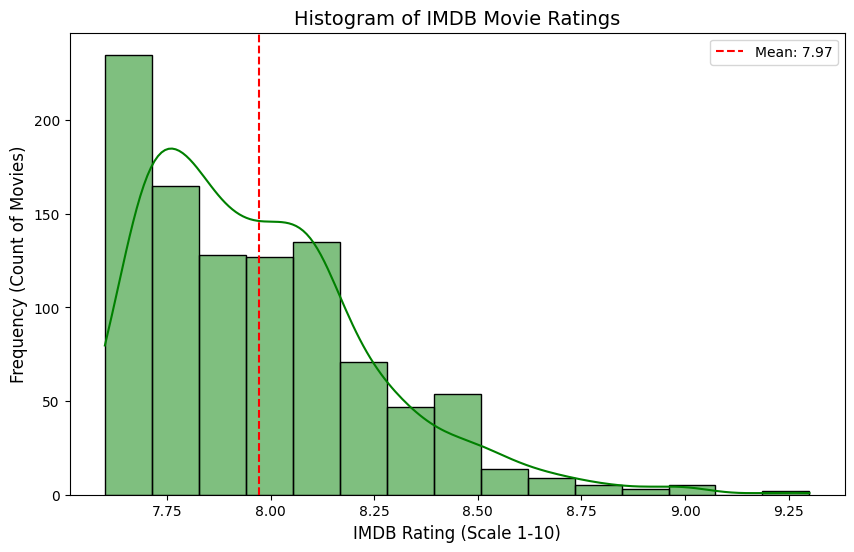

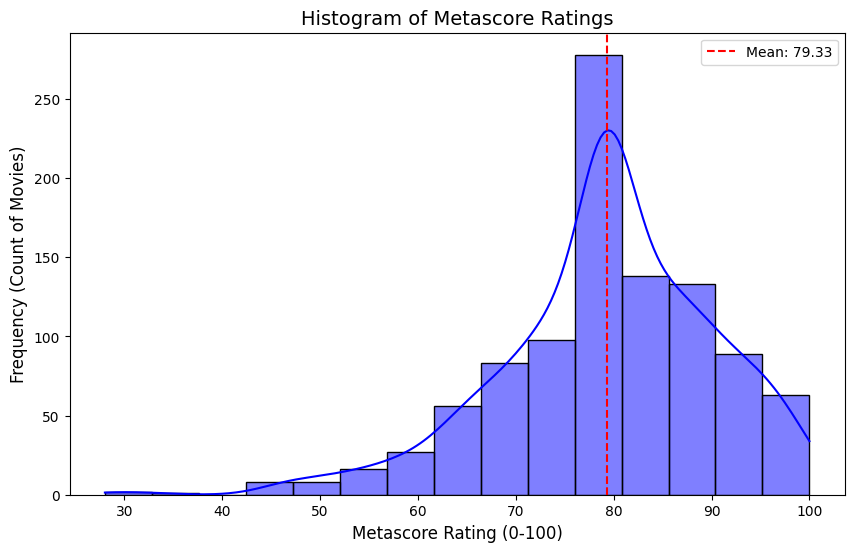

In [ ]:


plt.figure(figsize=(10, 6))
sns.histplot(dataset['rating'], bins=15, kde=True, color='green')

plt.title('Histogram of IMDB Movie Ratings', fontsize=14)
plt.xlabel('IMDB Rating (Scale 1-10)', fontsize=12)
plt.ylabel('Frequency (Count of Movies)', fontsize=12)

mean_rating = dataset['rating'].mean()
plt.axvline(mean_rating, color='red', linestyle='--', label=f'Mean: {mean_rating:.2f}')
plt.legend()

plt.figure(figsize=(10, 6))
sns.histplot(dataset['Metascore'], bins=15, kde=True, color='blue')

plt.title('Histogram of Metascore Ratings', fontsize=14)
plt.xlabel('Metascore Rating (0-100)', fontsize=12)
plt.ylabel('Frequency (Count of Movies)', fontsize=12)

mean_rating = dataset['Metascore'].mean()
plt.axvline(mean_rating, color='red', linestyle='--', label=f'Mean: {mean_rating:.2f}')
plt.legend()

##Scatterplot with regression line
The scatter plot identifies a positive correlation with a very narrow confidence interval demonstrating that the trend is significant however because of the residuals underfitting may be an issue with using a linear regression model for prediction

Text(0, 0.5, 'Metascore Rating')

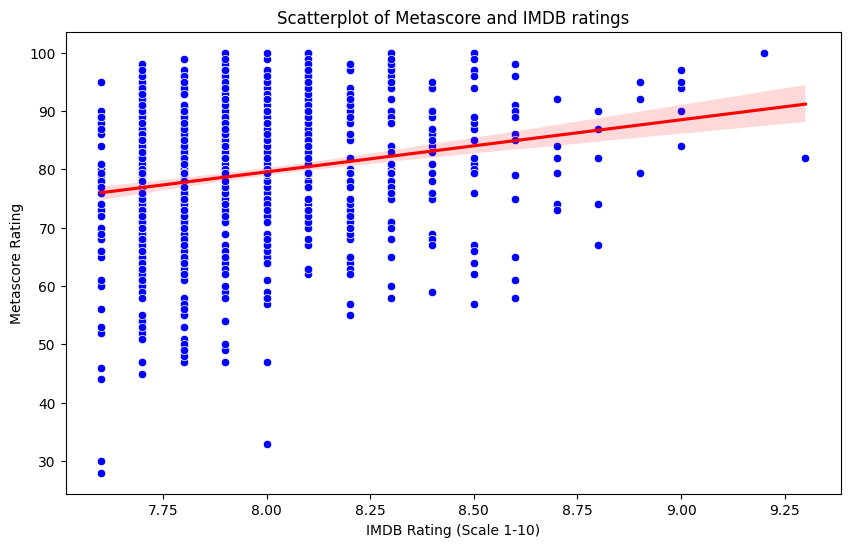

In [ ]:
plt.figure(figsize=(10, 6))


sns.scatterplot(x='rating', y='Metascore', data=dataset, color='blue')
sns.regplot(x='rating', y='Metascore', data=dataset, scatter=False, color='red')
plt.title('Scatterplot of Metascore and IMDB ratings')
plt.xlabel('IMDB Rating (Scale 1-10)')
plt.ylabel('Metascore Rating')

#Question One - Multiple Linear Regression

import libraries

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import sklearn.metrics as metrics

In [ ]:
from numpy.random import RandomState
#get x and y variables
X = dataset[['Metascore', 'year']]
Y = dataset['rating']
# split the data into 80/20
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
# randomstate 42 was used to get the same train and test split in different executions


Train model

In [ ]:
regressor = LinearRegression()
regressor.fit(X_train, Y_train)

LinearRegression()

Make prediction

In [ ]:
y_pred = regressor.predict(X_test)

Print results

In [ ]:
print(f"Intercept (c): {regressor.intercept_}")
print(f"Coefficients (m): {regressor.coef_}")
print(f"R-squared Score: {metrics.r2_score(Y_test, y_pred)}")
print(f"Mean Absolute Error: {metrics.mean_absolute_error(Y_test, y_pred)}")

Intercept (c): 7.208653953269431
Coefficients (m): [0.00570891 0.00015834]
R-squared Score: 0.043986234512379374
Mean Absolute Error: 0.198142896358759


Visualise results

The Linear regression model displays significant underfitting meaning that its failing to predict any of the higher rated movies

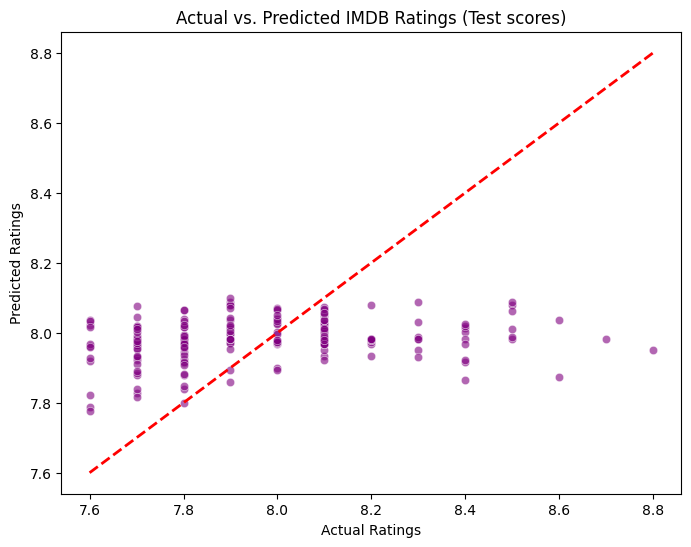

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=Y_test, y=y_pred, alpha=0.6, color='purple')

plt.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--', lw=2)

plt.title('Actual vs. Predicted IMDB Ratings (Test scores)')
plt.xlabel('Actual Ratings')
plt.ylabel('Predicted Ratings')
plt.show()

Polynomial regression coefficent of determination demonstrates that the relationship between these features are linear because its half that of the linear regressions 0.044

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


poly_model = make_pipeline(PolynomialFeatures(degree=2), LinearRegression())
poly_model.fit(X_train, Y_train)
y_pred_poly = poly_model.predict(X_test)
print(f"Polynomial R2 Score: {r2_score(Y_test, y_pred_poly)}")

Polynomial R2 Score: 0.021877384645356268


#Quesiton 2 - Decision Tree Classifier

In [ ]:
from sklearn.tree import DecisionTreeRegressor, plot_tree

In [ ]:
feat_q2 = ['duration_mins'] + [col for col in dataset.columns if col.startswith('age_')] # get all columns that start with 'age'
X_q2 = dataset[feat_q2]
Y_q2 = dataset['rating']
#split into train and test splits
X_trainQ2, X_testQ2, y_trainQ2, y_testQ2 = train_test_split(X_q2, Y_q2, test_size=0.2, random_state=42)

Fitting data to tree

In [ ]:
tree_q2 = DecisionTreeRegressor(max_depth=3, random_state=42)
tree_q2.fit(X_trainQ2, y_trainQ2)

DecisionTreeRegressor(max_depth=3, random_state=42)

In [ ]:
mae_q2 = mean_absolute_error(y_testQ2, tree_q2.predict(X_testQ2))
print(f"MAE: {mae_q2}")

MAE: 0.2043744853425565


###Visualise

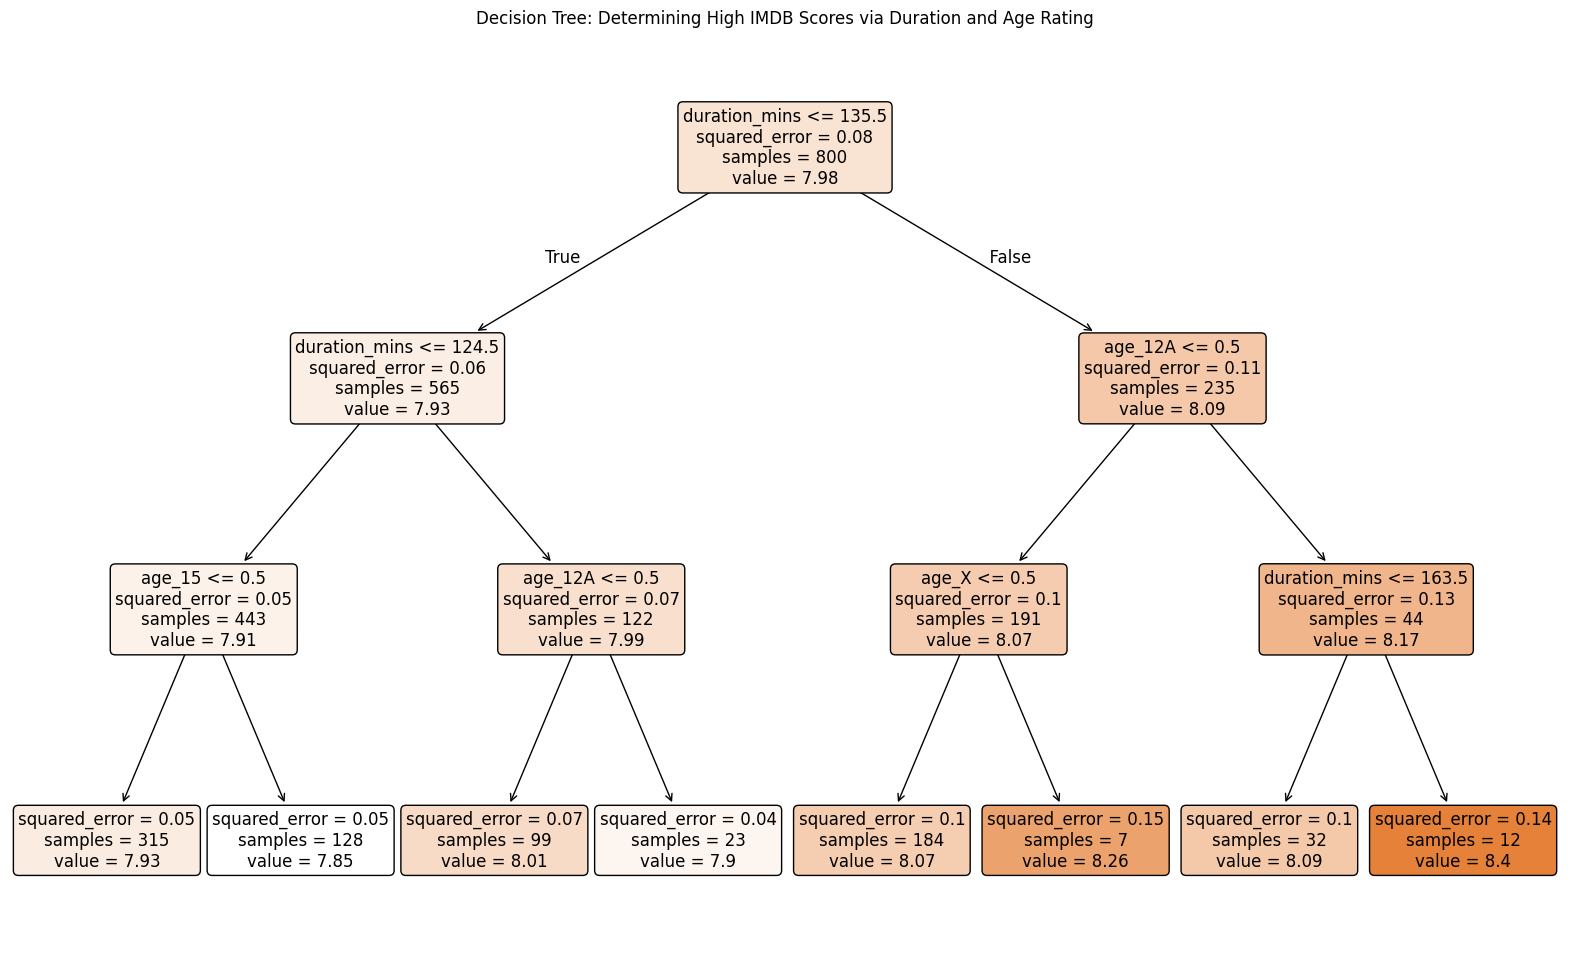

In [ ]:
plt.figure(figsize=(20,12))


plot_tree(tree_q2,
          feature_names=X_q2.columns,
          filled=True,
          rounded=True,
          precision=2,
          fontsize=12)

plt.title("Decision Tree: Determining High IMDB Scores via Duration and Age Rating")

plt.show()


#Question 3 Random Forest

In [ ]:
from sklearn.ensemble import RandomForestRegressor #import libraries
from sklearn.preprocessing import LabelEncoder

In [ ]:
all_features = ['Metascore', 'year', 'duration_mins'] + [col for col in dataset.columns if col.startswith('age_')] # get all features
X_q3 = dataset[all_features]
Y_q3 = dataset['rating']

In [ ]:
X_trainQ3, X_testQ3, Y_trainQ3, Y_testQ3 = train_test_split(X_q3, Y_q3, test_size=0.2, random_state=42) # divide into train test split

In [ ]:
rf_model = RandomForestRegressor(n_estimators=100, max_depth=7, random_state=42)
rf_model.fit(X_trainQ3, Y_trainQ3) # fit the model to the data

RandomForestRegressor(max_depth=7, random_state=42)

In [ ]:

y_pred = rf_model.predict(X_testQ3) # model prediction

mse = mean_squared_error(Y_testQ3, y_pred) # get mse and R-squared
print("Mean Squared Error:", mse)

r2 = r2_score(Y_testQ3, y_pred)
print("R-squared:", r2)

Mean Squared Error: 0.058885888656388524
R-squared: 0.05797273775069456


In [ ]:
importances = rf_model.feature_importances_ # get the feature importance
feature_importance_df = pd.DataFrame({'Feature': all_features, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

##Visualise
The barchart shows a rank of each feature and how important they are. It identifies that duration is the most important facotr deciding the movies success while age limits dont hold much influence

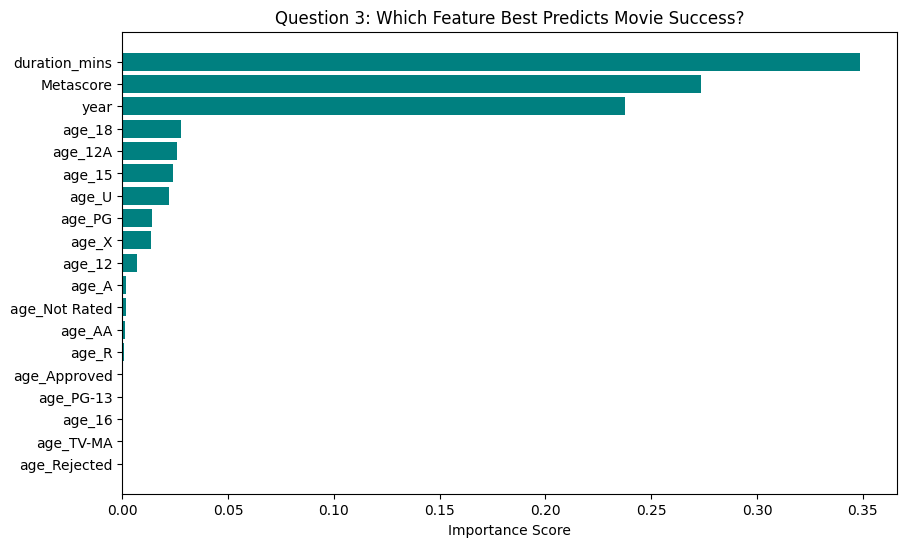

In [ ]:
plt.figure(figsize=(10, 6)) # display in bar chart
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='teal')
plt.xlabel('Importance Score')
plt.title('Question 3: Which Feature Best Predicts Movie Success?')
plt.gca().invert_yaxis()
plt.show()